In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Helper functions (carried over from previous notebook)

In [16]:
def init_r(N, kind="uniform", scale=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if kind == "uniform":
        return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian":
        return rng.normal(0.0, scale, size=N)
    if kind == "zeros":
        return np.zeros(N)
    if kind == "ones":
        return np.ones(N)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")


def make_W(N, J, rng, kind="gaussian", p=None):
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)
    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")


def simulate(r_0, W, time):
    r_0 = np.asarray(r_0, dtype=float)
    W   = np.asarray(W,   dtype=float)
    dt  = time[1] - time[0]
    T   = len(time)
    N   = len(r_0)
    R   = np.empty((T, N))
    R[0] = r_0
    for t in range(T - 1):
        r = R[t]
        R[t + 1] = r + dt * (-r + np.tanh(W @ r))
    return R


## 1. Generate the Lorenz Attractor

We integrate the classic Lorenz-63 system

$$\dot{x} = \sigma(y - x), \quad \dot{y} = x(\rho - z) - y, \quad \dot{z} = xy - \beta z$$

with the standard butterfly parameters $\sigma=10,\;\rho=28,\;\beta=8/3$.  
`generate_lorenz` handles all integration and splitting; `plot_lorenz` is the dedicated visualisation call.


In [17]:
SIGMA, RHO, BETA = 10.0, 28.0, 8 / 3


def generate_lorenz(
    dt=0.01, # s.t. graph is smoother 
    T_total=10000.0,
    T_transient=50.0,
    T_train=60.0,
    T_test=20.0,
    ic=(1.0, 0.0, 0.0),
    sigma=SIGMA, rho=RHO, beta=BETA,
):
    """
    Integrate the Lorenz-63 system and return labelled train / test splits.

    Returns
    -------
    dict with keys:
        t_tr, u_tr   – training time vector and trajectory  (T_tr, 3)
        t_te, u_te   – test     time vector and trajectory  (T_te, 3)
        dt           – time step used
    """
    def _lorenz(t, state):
        x, y, z = state
        return [sigma * (y - x),
                x * (rho - z) - y,
                x * y - beta * z]

    t_eval = np.arange(0, T_total, dt)
    sol    = solve_ivp(_lorenz, [0, T_total], list(ic),
                       t_eval=t_eval, method="RK23", rtol=1e-9, atol=1e-11)

    t_full = sol.t
    xyz    = sol.y.T          # (T, 3)

    i_trans = int(T_transient / dt)
    i_train = i_trans + int(T_train  / dt)
    i_test  = i_train + int(T_test   / dt)

    result = dict(
        t_tr = t_full[i_trans:i_train],
        u_tr = xyz   [i_trans:i_train],
        t_te = t_full[i_train:i_test],
        u_te = xyz   [i_train:i_test],
        dt   = dt,
    )

    print(f"Training steps : {len(result['t_tr']):,}  ({T_train} time units)")
    print(f"Test steps     : {len(result['t_te']):,}  ({T_test}  time units)")
    return result

lorenz_data = generate_lorenz()

Training steps : 6,000  (60.0 time units)
Test steps     : 2,000  (20.0  time units)


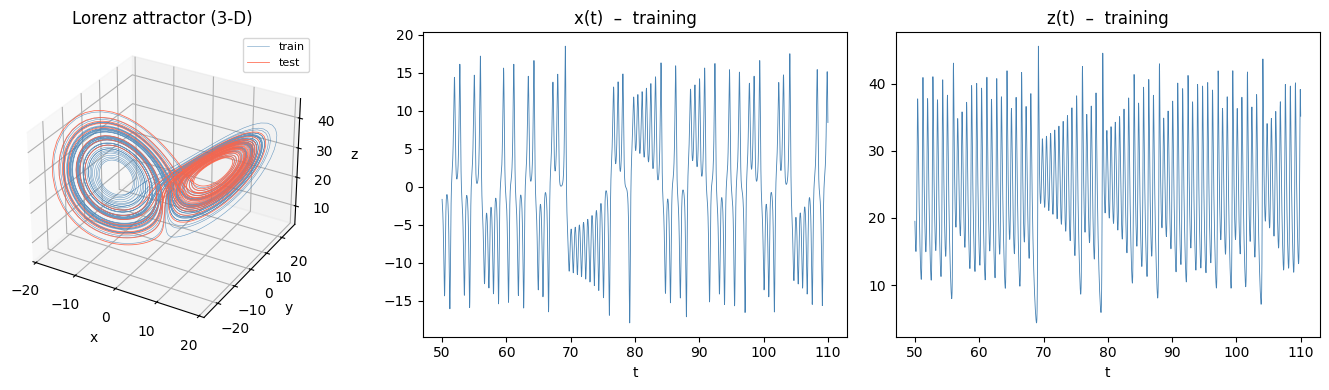

In [18]:
def plot_lorenz(lorenz_data):
    """
    Plot the Lorenz attractor in 3-D and show two representative time series.

    Parameters
    ----------
    lorenz_data : dict returned by generate_lorenz()
    """
    t_tr, u_tr = lorenz_data["t_tr"], lorenz_data["u_tr"]
    t_te, u_te = lorenz_data["t_te"], lorenz_data["u_te"]

    fig = plt.figure(figsize=(14, 4))

    # 3-D butterfly
    ax3d = fig.add_subplot(131, projection="3d")
    ax3d.plot(*u_tr.T, lw=0.4, color="steelblue", alpha=0.8, label="train")
    ax3d.plot(*u_te.T, lw=0.6, color="tomato",    alpha=0.9, label="test")
    ax3d.set_title("Lorenz attractor (3-D)")
    ax3d.set_xlabel("x"); ax3d.set_ylabel("y"); ax3d.set_zlabel("z")
    ax3d.legend(fontsize=8)

    # x(t) and z(t) on training window
    for ax, comp, label in zip(
        [fig.add_subplot(132), fig.add_subplot(133)],
        [u_tr[:, 0], u_tr[:, 2]],
        ["x(t)  –  training", "z(t)  –  training"],
    ):
        ax.plot(t_tr, comp, lw=0.6, color="steelblue")
        ax.set_title(label)
        ax.set_xlabel("t")

    plt.tight_layout()
    plt.show()

plot_lorenz(lorenz_data)

The 3-D butterfly portrait confirms the attractor topology. The $x(t)$ and $z(t)$ panels show the quasi-periodic, chaotic character of the signal that the reservoir will learn to reproduce autonomously.

## 2. Build the Reservoir

A **reservoir** is a large, randomly-connected recurrent network whose weights are **fixed**.  
`build_reservoir` allocates and returns $W_{\text{res}}$ and $W_{\text{in}}$; `plot_reservoir_summary` shows their statistics.

| Hyper-parameter | Symbol | Value |
|---|---|---|
| Reservoir size | $N$ | 250 |
| Recurrent coupling | $J$ | 0.8 |
| Input weight scale | $\sigma_{\text{in}}$ | 1.0 |


In [19]:
def build_reservoir(n_in, N_res=250, J_res=0.8, sigma_in=1.0, seed=42):
    """
    Construct the fixed random matrices of the reservoir.

    Parameters
    ----------
    n_in    : int   – dimensionality of the input signal
    N_res   : int   – number of reservoir neurons
    J_res   : float – recurrent coupling strength
    sigma_in: float – std of input weights
    seed    : int   – RNG seed for reproducibility

    Returns
    -------
    dict with keys:
        W_res           – recurrent weight matrix  (N_res, N_res)
        W_in            – input weight matrix      (N_res, n_in)
        spectral_radius – largest |eigenvalue| of W_res
        N_res, J_res    – stored hyper-parameters
    """
    rng   = np.random.default_rng(seed)
    W_res = make_W(N_res, J_res, rng=rng, kind="gaussian")
    W_in  = rng.normal(0.0, sigma_in / np.sqrt(n_in), size=(N_res, n_in))
    rho   = float(np.max(np.abs(np.linalg.eigvals(W_res))))

    print(f"W_res  shape : {W_res.shape}   spectral radius ≈ {rho:.3f}")
    print(f"W_in   shape : {W_in.shape}")
    print(f"Regime : {'chaotic (J > 1)' if J_res > 1 else 'stable (J ≤ 1)'}")

    return dict(W_res=W_res, W_in=W_in, spectral_radius=rho,
                N_res=N_res, J_res=J_res)

n_in      = lorenz_data["u_tr"].shape[1]   # 3
reservoir = build_reservoir(n_in=n_in)

W_res  shape : (250, 250)   spectral radius ≈ 0.853
W_in   shape : (250, 3)
Regime : stable (J ≤ 1)


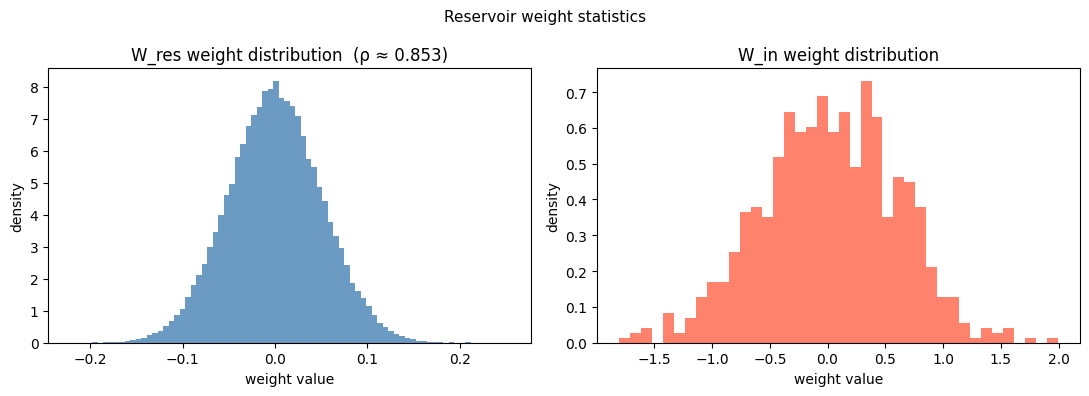

In [20]:
def plot_reservoir_summary(reservoir):
    """
    Visualise the weight distributions of the reservoir matrices.

    Parameters
    ----------
    reservoir : dict returned by build_reservoir()
    """
    W_res = reservoir["W_res"]
    W_in  = reservoir["W_in"]
    rho   = reservoir["spectral_radius"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].hist(W_res.ravel(), bins=80, color="steelblue", alpha=0.8, density=True)
    axes[0].set_title(f"W_res weight distribution  (ρ ≈ {rho:.3f})")
    axes[0].set_xlabel("weight value"); axes[0].set_ylabel("density")

    axes[1].hist(W_in.ravel(),  bins=40, color="tomato",    alpha=0.8, density=True)
    axes[1].set_title("W_in weight distribution")
    axes[1].set_xlabel("weight value"); axes[1].set_ylabel("density")

    plt.suptitle("Reservoir weight statistics", fontsize=11)
    plt.tight_layout()
    plt.show()

plot_reservoir_summary(reservoir)

Both distributions are Gaussian by construction. The spectral radius $\rho \approx J = 1.5$ places the reservoir firmly in the chaotic regime, maximising the echo-state property.

## 4. Run the Reservoir — Collect States

`collect_states` drives the reservoir with the Lorenz training signal and returns the state matrix after the wash-out period.  
`plot_reservoir_states` overlays the input signal with a sample of neuron activations.


In [21]:
def collect_states(lorenz_data, reservoir, N_washout=200, alpha=1.0):
    """
    Drive the reservoir open-loop with the training input u_tr.

    Parameters
    ----------
    lorenz_data  : dict from generate_lorenz()
    reservoir    : dict from build_reservoir()
    N_washout    : int   – warm-up steps to discard
    alpha        : float – leak rate  (1 = no leak)

    Returns
    -------
    dict with keys:
        R_train      – state matrix after wash-out  (T_tr - N_washout, N_res)
        R_train_full – full state matrix            (T_tr, N_res)
        u_target     – aligned Lorenz targets       (T_tr - N_washout, 3)
        t_plot       – aligned time vector
        N_washout, alpha
    """
    u_tr  = lorenz_data["u_tr"]
    t_tr  = lorenz_data["t_tr"]
    W_res = reservoir["W_res"]
    W_in  = reservoir["W_in"]
    N     = reservoir["N_res"]

    T, n_in = u_tr.shape
    R = np.empty((T, N))
    r = np.zeros(N)

    for t in range(T):
        r = (1 - alpha) * r + alpha * np.tanh(W_res @ r + W_in @ u_tr[t])
        R[t] = r

    R_full   = R
    R_train  = R_full  [N_washout:]
    u_target = u_tr    [N_washout:]
    t_plot   = t_tr    [N_washout:]

    print(f"State matrix shape (after wash-out): {R_train.shape}")
    print(f"Target matrix shape                : {u_target.shape}")

    return dict(R_train=R_train, R_train_full=R_full,
                u_target=u_target, t_plot=t_plot,
                N_washout=N_washout, alpha=alpha)

states_data = collect_states(lorenz_data, reservoir)

State matrix shape (after wash-out): (5800, 250)
Target matrix shape                : (5800, 3)


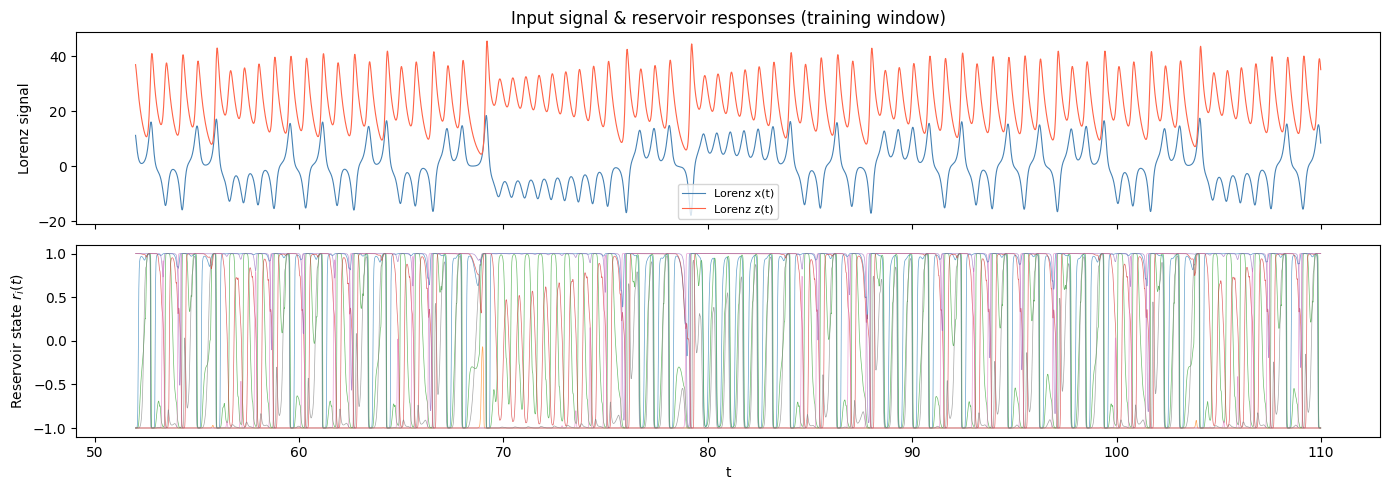

In [22]:
def plot_reservoir_states(lorenz_data, states_data, n_neurons=8):
    """
    Plot the Lorenz input signal alongside a sample of reservoir neuron traces.

    Parameters
    ----------
    lorenz_data  : dict from generate_lorenz()
    states_data  : dict from collect_states()
    n_neurons    : int – how many reservoir neurons to overlay
    """
    t_plot   = states_data["t_plot"]
    u_target = states_data["u_target"]
    R_train  = states_data["R_train"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

    axes[0].plot(t_plot, u_target[:, 0], lw=0.8, color="steelblue", label="Lorenz x(t)")
    axes[0].plot(t_plot, u_target[:, 2], lw=0.8, color="tomato",    label="Lorenz z(t)")
    axes[0].set_ylabel("Lorenz signal")
    axes[0].legend(fontsize=8)
    axes[0].set_title("Input signal & reservoir responses (training window)")

    for i in range(n_neurons):
        axes[1].plot(t_plot, R_train[:, i], lw=0.5, alpha=0.7)
    axes[1].set_ylabel(r"Reservoir state $r_i(t)$")
    axes[1].set_xlabel("t")

    plt.tight_layout()
    plt.show()

plot_reservoir_states(lorenz_data, states_data)

The reservoir neurons display diverse, non-linear projections of the Lorenz signal — the rich feature basis that Ridge regression will exploit to reconstruct $x,y,z$.

## 5. Train the Readout — Ridge Regression

$$W_{\text{out}} = \left(\mathbf{R}^\top \mathbf{R} + \lambda I\right)^{-1}\mathbf{R}^\top \mathbf{U}_{\text{target}}$$

`train_readout` solves this closed-form problem and reports training RMSE.  
`plot_teacher_forcing` shows how well the readout reconstructs the training signal.


In [34]:
def train_readout(states_data, lambda_reg=2e-6):
    """
    Solve the Ridge regression problem to find W_out.

    Parameters
    ----------
    states_data : dict from collect_states()
    lambda_reg  : float – regularisation strength λ

    Returns
    -------
    dict with keys:
        W_out        – output weight matrix  (N_res, 3)
        u_pred_train – teacher-forcing predictions on training data
        rmse_train   – per-component RMSE  (3,)
    """
    R_train  = states_data["R_train"]    # (T, N)
    u_target = states_data["u_target"]   # (T, 3)
    N        = R_train.shape[1]

    RtR   = R_train.T @ R_train
    RtU   = R_train.T @ u_target
    W_out = np.linalg.solve(RtR + lambda_reg * np.eye(N), RtU)

    u_pred_train = R_train @ W_out
    rmse_train   = np.sqrt(np.mean((u_pred_train - u_target) ** 2, axis=0))

    print(f"W_out shape : {W_out.shape}")
    print("Training RMSE (x, y, z):", np.round(rmse_train, 6))

    return dict(W_out=W_out, u_pred_train=u_pred_train, rmse_train=rmse_train)

readout_data = train_readout(states_data)

W_out shape : (250, 3)
Training RMSE (x, y, z): [0.153041 0.139953 0.357829]


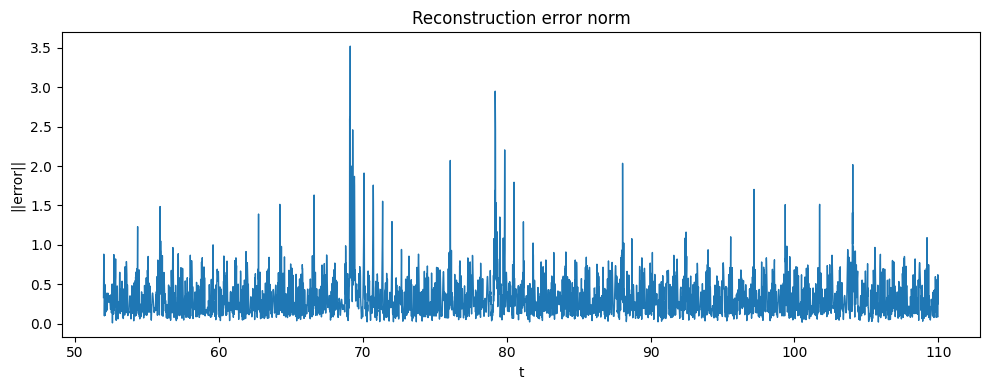

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reconstruction_error(states_data, readout_data, mode="raw"):
    """
    Plot reconstruction error between Lorenz ground truth and RC readout.

    Parameters
    ----------
    states_data  : dict
        Output from collect_states()
    readout_data : dict
        Output from train_readout()
    mode : str
        "raw"  -> signed error (true - pred)
        "abs"  -> absolute error
        "norm" -> L2 norm over (x,y,z)
    """
    t_plot       = states_data["t_plot"]
    u_true       = states_data["u_target"]
    u_pred       = readout_data["u_pred_train"]

    error = u_true - u_pred

    if mode == "norm":
        error_norm = np.linalg.norm(error, axis=1)

        plt.figure(figsize=(10, 4))
        plt.plot(t_plot, error_norm, lw=1)
        plt.title("Reconstruction error norm")
        plt.xlabel("t")
        plt.ylabel("||error||")
        plt.tight_layout()
        plt.show()
        return

    if mode == "abs":
        error = np.abs(error)
        title = "Absolute reconstruction error"
        labels = ["|x error|", "|y error|", "|z error|"]
    else:
        title = "Signed reconstruction error (true - pred)"
        labels = ["x error", "y error", "z error"]

    colors = ["steelblue", "seagreen", "tomato"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    for i, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
        ax.plot(t_plot, error[:, i], lw=0.8, color=col)
        ax.axhline(0, color="k", lw=0.5, alpha=0.5)
        ax.set_ylabel(lbl)

    axes[0].set_title(title)
    axes[-1].set_xlabel("t")

    plt.tight_layout()
    plt.show()

plot_reconstruction_error(states_data, readout_data, mode="norm")

With teacher-forcing the readout reconstructs the three Lorenz components almost perfectly on the training set, confirming that the reservoir states encode sufficient information about the attractor.

## 6. Closed-Loop (Autonomous) Prediction

Once $W_{\text{out}}$ is trained the loop is **closed**: the readout at step $t$ feeds back as the reservoir input at step $t+1$.

`run_closed_loop` performs the autonomous rollout and computes metrics.  
`plot_closed_loop` provides three complementary views of the result.


In [36]:
def run_closed_loop(lorenz_data, reservoir, states_data, readout_data):
    """
    Autonomous (closed-loop) prediction over the test horizon.

    Parameters
    ----------
    lorenz_data  : dict from generate_lorenz()
    reservoir    : dict from build_reservoir()
    states_data  : dict from collect_states()
    readout_data : dict from train_readout()

    Returns
    -------
    dict with keys:
        U_cl        – predicted trajectory  (T_te, 3)
        abs_err     – pointwise |error|      (T_te, 3)
        rmse_cl     – per-component RMSE    (3,)
        valid_time  – first time step where mean |error| > 30 % of attractor std
        threshold   – threshold value used
    """
    W_res  = reservoir["W_res"]
    W_in   = reservoir["W_in"]
    W_out  = readout_data["W_out"]
    alpha  = states_data["alpha"]
    r      = states_data["R_train_full"][-1].copy()   # seed from last training state

    t_te   = lorenz_data["t_te"]
    u_te   = lorenz_data["u_te"]
    dt     = lorenz_data["dt"]
    n_steps = len(t_te)
    n_out   = W_out.shape[1]

    U_pred = np.empty((n_steps, n_out))
    for t in range(n_steps):
        u_hat = r @ W_out
        r     = (1 - alpha) * r + alpha * np.tanh(W_res @ r + W_in @ u_hat)
        U_pred[t] = u_hat

    abs_err    = np.abs(U_pred - u_te)
    rmse_cl    = np.sqrt(np.mean((U_pred - u_te) ** 2, axis=0))
    threshold  = 0.3 * u_te.std(axis=0).mean()
    valid_steps = int(np.argmax(abs_err.mean(axis=1) > threshold))
    valid_time  = valid_steps * dt

    print("Closed-loop RMSE (x, y, z):", np.round(rmse_cl, 4))
    print(f"Valid prediction time (30 % std threshold) ≈ {valid_time:.2f} LTU")

    return dict(U_cl=U_pred, abs_err=abs_err, rmse_cl=rmse_cl,
                valid_time=valid_time, threshold=threshold)

cl_data = run_closed_loop(lorenz_data, reservoir, states_data, readout_data)

Closed-loop RMSE (x, y, z): [ 975.3987   74.457  1195.0669]
Valid prediction time (30 % std threshold) ≈ 0.05 LTU


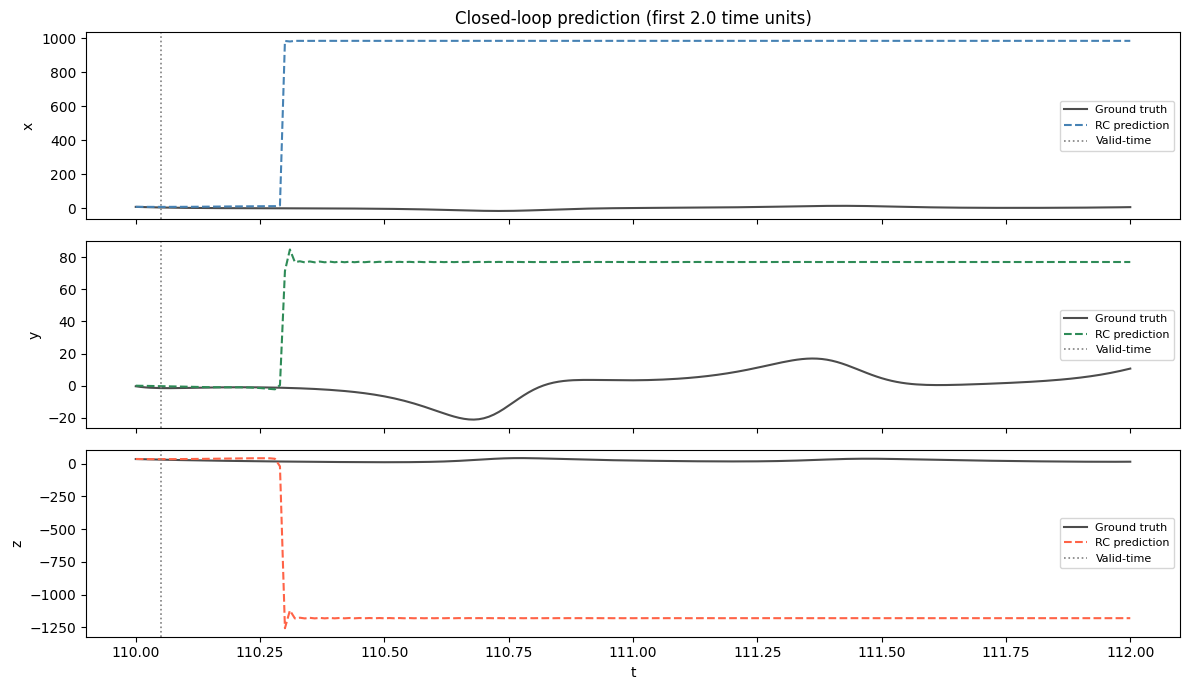

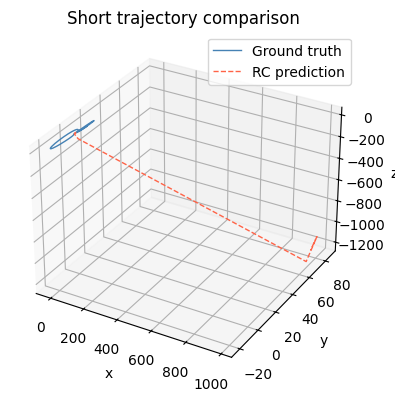

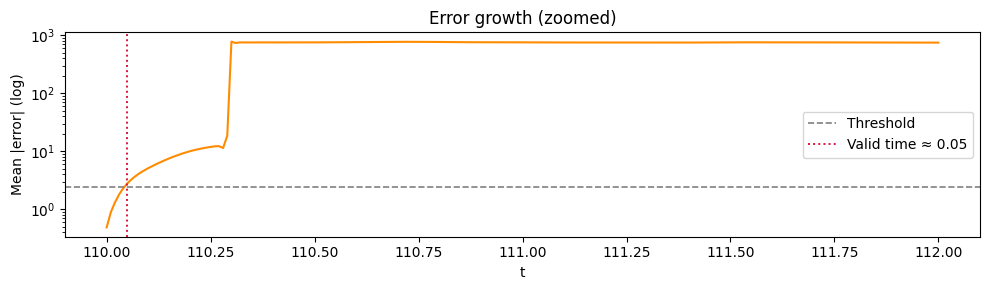

In [37]:
def plot_closed_loop(lorenz_data, cl_data, t_window=2.0):
    """
    Same as before, but only plots an initial short time window.

    Parameters
    ----------
    t_window : float
        Length of time (in same units as t_te) to display from start.
    """
    t_te       = lorenz_data["t_te"]
    u_te       = lorenz_data["u_te"]
    U_cl       = cl_data["U_cl"]
    abs_err    = cl_data["abs_err"]
    valid_time = cl_data["valid_time"]
    threshold  = cl_data["threshold"]

    # ── Select small window ────────────────────────────────────────────────
    t0 = t_te[0]
    mask = t_te <= t0 + t_window

    t_plot   = t_te[mask]
    u_plot   = u_te[mask]
    Ucl_plot = U_cl[mask]
    err_plot = abs_err[mask]

    labels = ["x", "y", "z"]
    colors = ["steelblue", "seagreen", "tomato"]

    # ── Panel 1: time series ─────────────────────────────────────────────
    fig1, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for i, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
        ax.plot(t_plot, u_plot[:, i], lw=1.5, color="k", alpha=0.7, label="Ground truth")
        ax.plot(t_plot, Ucl_plot[:, i], lw=1.5, color=col, ls="--", label="RC prediction")

        if valid_time <= t_window:
            ax.axvline(t0 + valid_time, color="grey", ls=":", lw=1.2, label="Valid-time")

        ax.set_ylabel(lbl)
        ax.legend(fontsize=8)

    axes[0].set_title(f"Closed-loop prediction (first {t_window} time units)")
    axes[-1].set_xlabel("t")
    plt.tight_layout()
    plt.show()

    # ── Panel 2: 3D attractor (short segment) ─────────────────────────────
    fig2 = plt.figure(figsize=(10, 4))
    ax = fig2.add_subplot(111, projection="3d")

    ax.plot(*u_plot.T, lw=1.0, color="steelblue", label="Ground truth")
    ax.plot(*Ucl_plot.T, lw=1.0, color="tomato", ls="--", label="RC prediction")

    ax.set_title("Short trajectory comparison")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Panel 3: error divergence ────────────────────────────────────────
    mean_abs_err = err_plot.mean(axis=1)

    fig3, ax = plt.subplots(figsize=(10, 3))
    ax.semilogy(t_plot, mean_abs_err, lw=1.5, color="darkorange")

    ax.axhline(threshold, color="grey", ls="--", lw=1.2, label="Threshold")

    if valid_time <= t_window:
        ax.axvline(t0 + valid_time, color="crimson", ls=":", lw=1.4,
                   label=f"Valid time ≈ {valid_time:.2f}")

    ax.set_xlabel("t")
    ax.set_ylabel("Mean |error| (log)")
    ax.set_title("Error growth (zoomed)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_closed_loop(lorenz_data, cl_data, t_window=2.0)